In [90]:
import pandas as pd

In [92]:
df=pd.read_csv("Desktop/FYP/Data/Training.csv")

In [94]:
df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [96]:
df.shape

(4920, 133)

In [98]:
df["prognosis"].unique()

array(['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis',
       'Drug Reaction', 'Peptic ulcer diseae', 'AIDS', 'Diabetes ',
       'Gastroenteritis', 'Bronchial Asthma', 'Hypertension ', 'Migraine',
       'Cervical spondylosis', 'Paralysis (brain hemorrhage)', 'Jaundice',
       'Malaria', 'Chicken pox', 'Dengue', 'Typhoid', 'hepatitis A',
       'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E',
       'Alcoholic hepatitis', 'Tuberculosis', 'Common Cold', 'Pneumonia',
       'Dimorphic hemmorhoids(piles)', 'Heart attack', 'Varicose veins',
       'Hypothyroidism', 'Hyperthyroidism', 'Hypoglycemia',
       'Osteoarthristis', 'Arthritis',
       '(vertigo) Paroymsal  Positional Vertigo', 'Acne',
       'Urinary tract infection', 'Psoriasis', 'Impetigo'], dtype=object)

In [100]:
len(df["prognosis"].unique())

41

                                                        TRAIN TEST SPLIT

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [105]:
X= df.drop("prognosis", axis=1)
y= df["prognosis"]

In [107]:
y

0                              Fungal infection
1                              Fungal infection
2                              Fungal infection
3                              Fungal infection
4                              Fungal infection
                         ...                   
4915    (vertigo) Paroymsal  Positional Vertigo
4916                                       Acne
4917                    Urinary tract infection
4918                                  Psoriasis
4919                                   Impetigo
Name: prognosis, Length: 4920, dtype: object

In [109]:
label=LabelEncoder()
label.fit(y)
Y=label.transform(y)

In [195]:
import numpy as np
np.set_printoptions(threshold=np.inf)  # Disable truncation
unique_Y = pd.Series(Y).drop_duplicates().tolist()
print(unique_Y)

[15, 4, 16, 9, 14, 33, 1, 12, 17, 6, 23, 30, 7, 32, 28, 29, 8, 11, 37, 40, 19, 20, 21, 22, 3, 36, 10, 34, 13, 18, 39, 26, 24, 25, 31, 5, 0, 2, 38, 35, 27]


In [200]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y, test_size=0.3,random_state=20)

In [202]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((3444, 132), (1476, 132), (3444,), (1476,))

                                                            MODEL TRAINING 

In [205]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


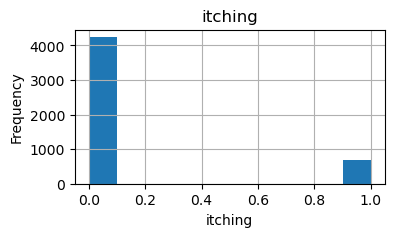

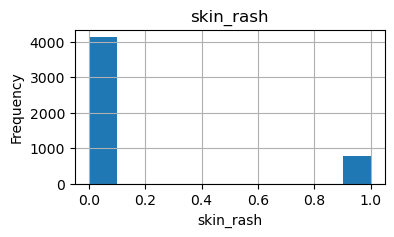

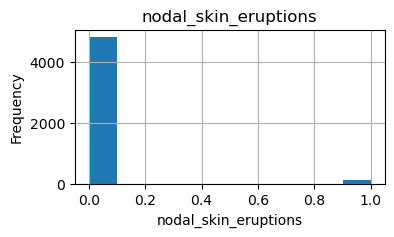

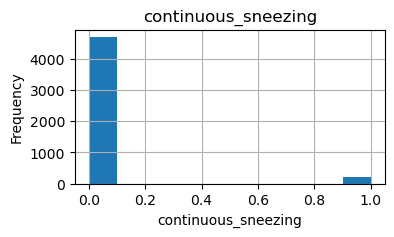

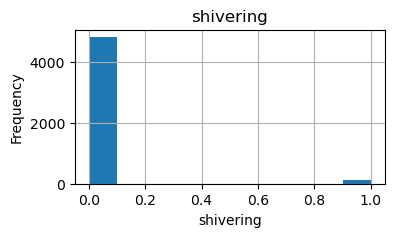

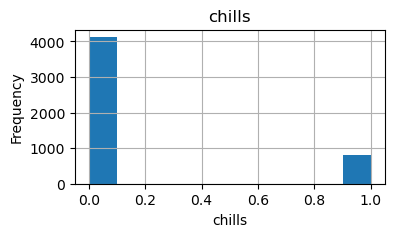

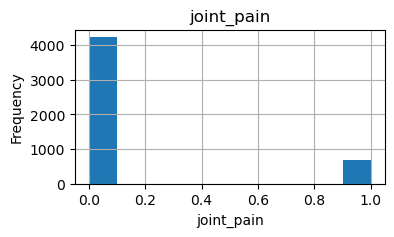

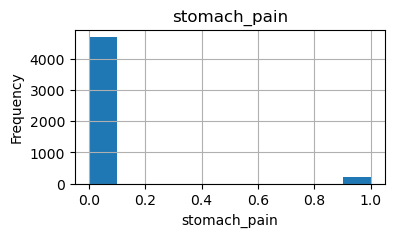

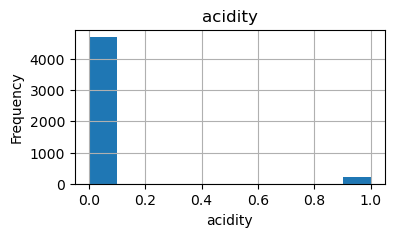

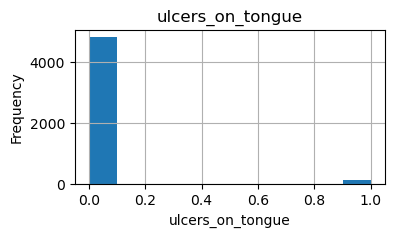

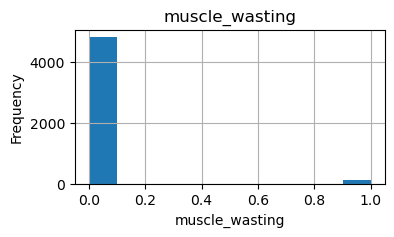

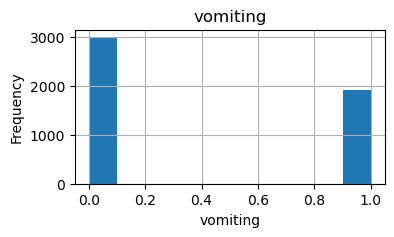

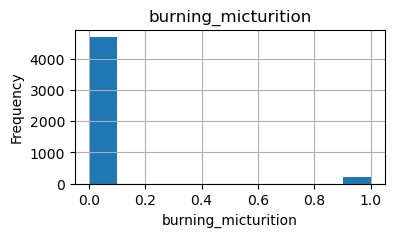

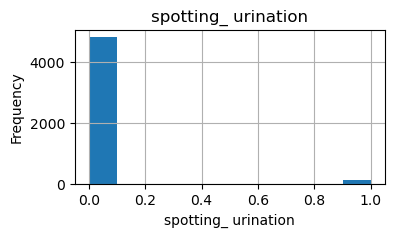

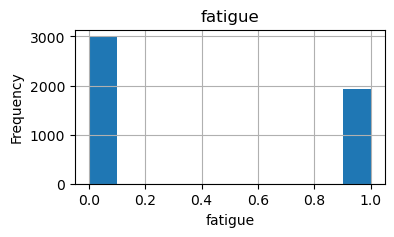

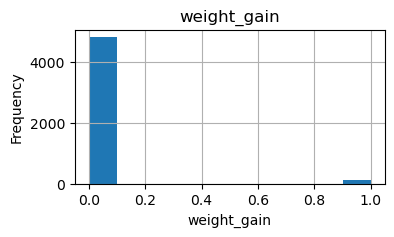

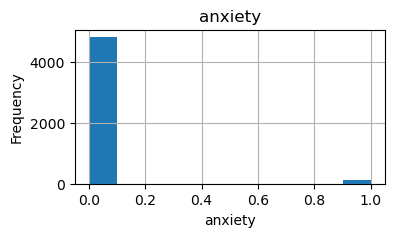

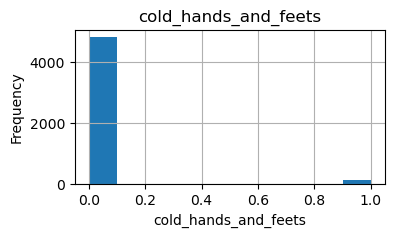

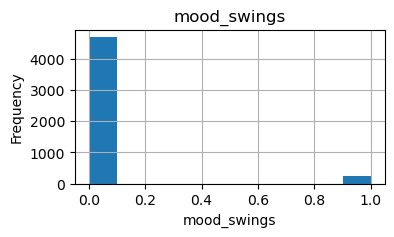

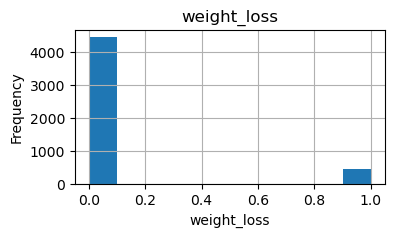

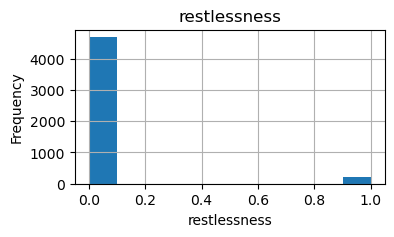

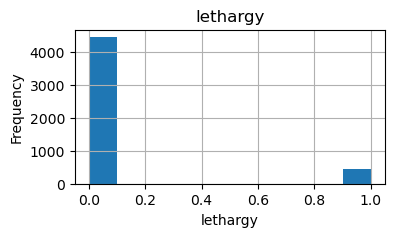

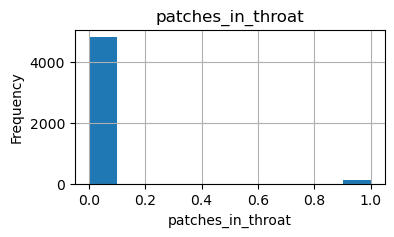

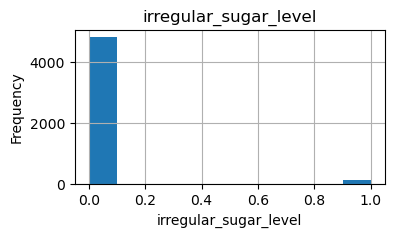

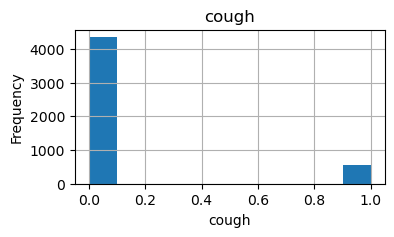

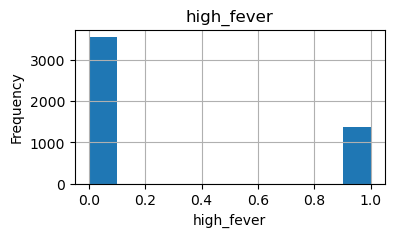

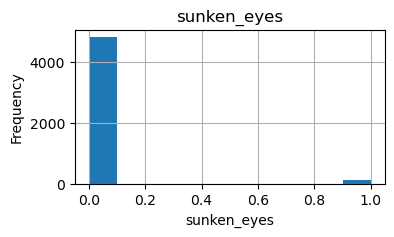

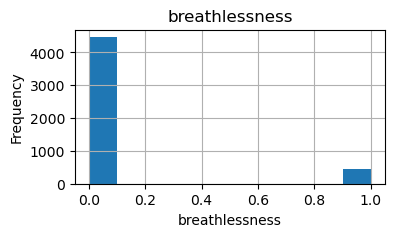

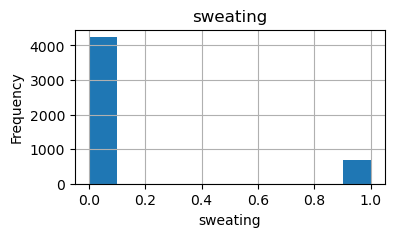

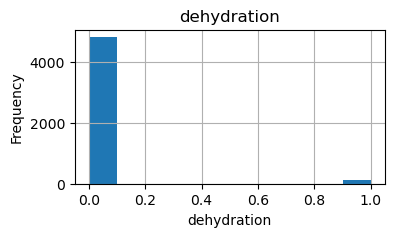

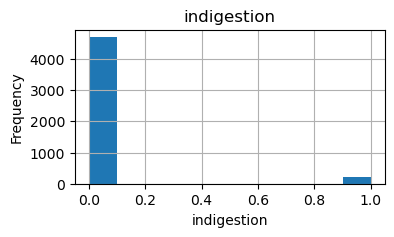

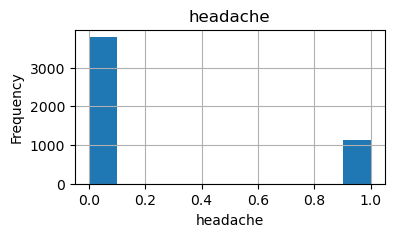

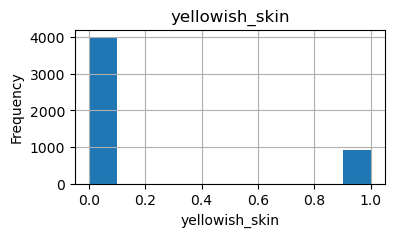

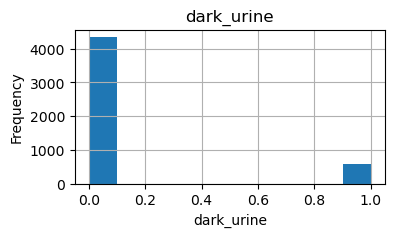

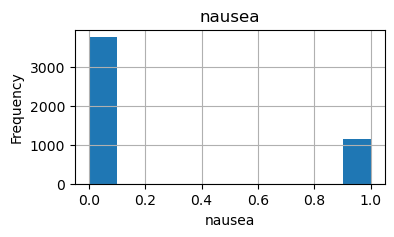

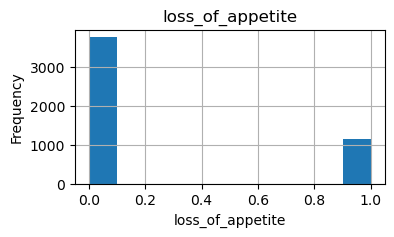

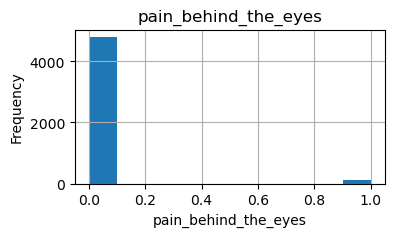

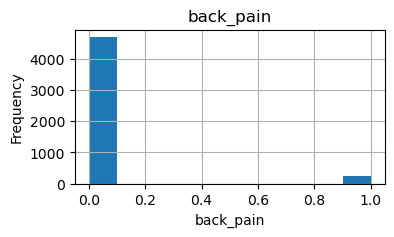

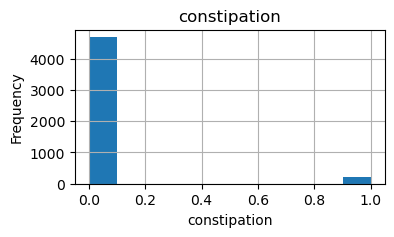

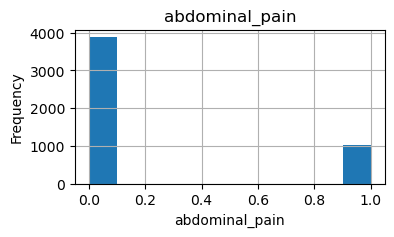

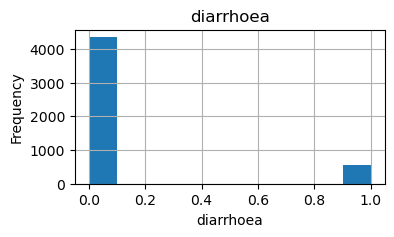

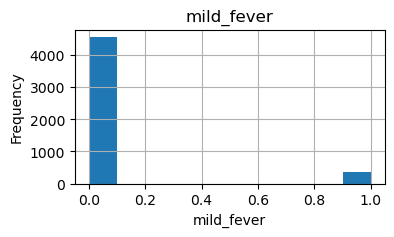

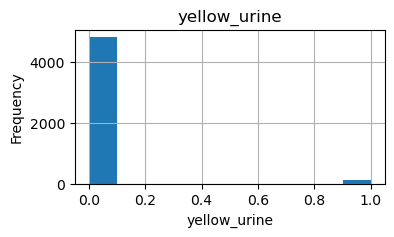

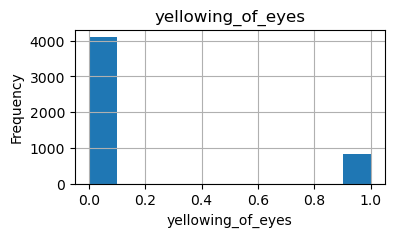

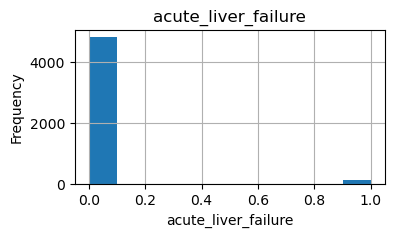

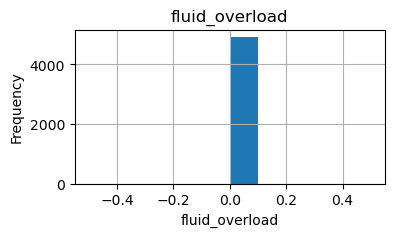

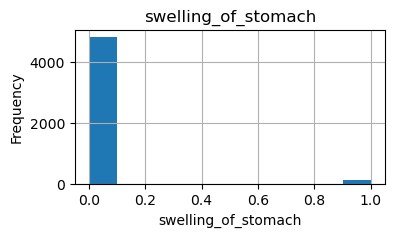

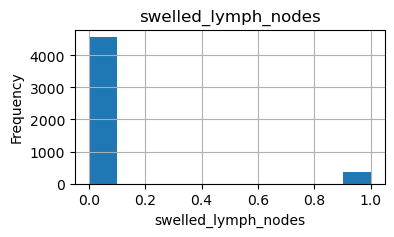

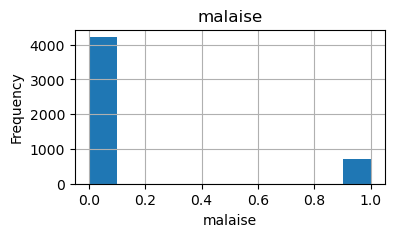

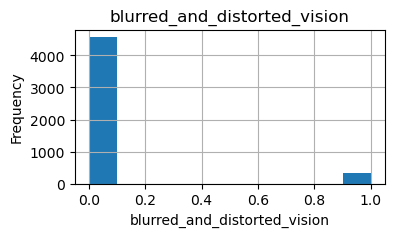

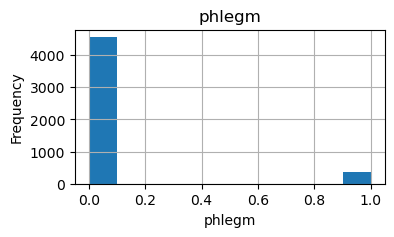

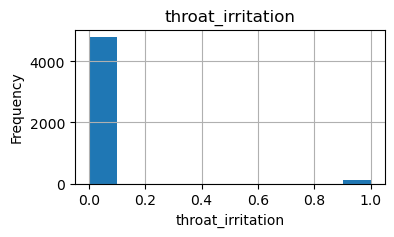

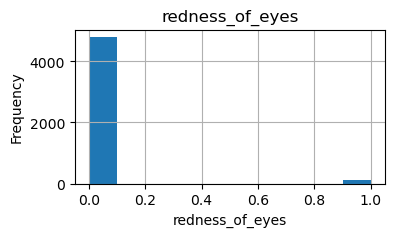

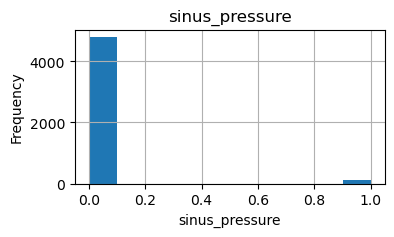

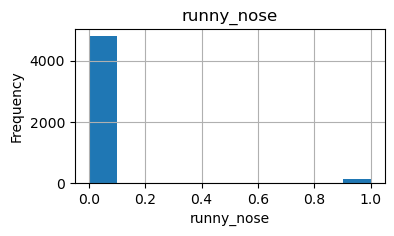

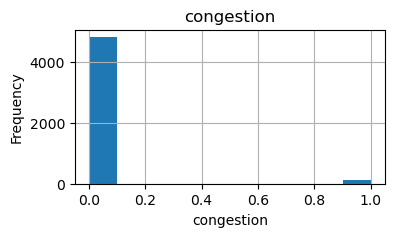

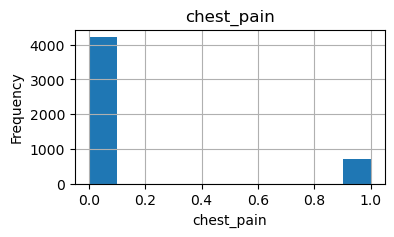

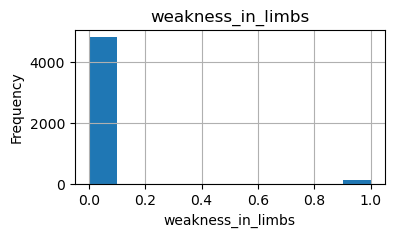

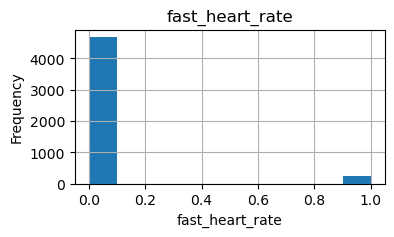

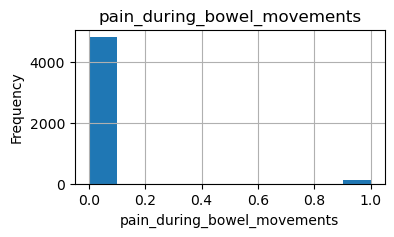

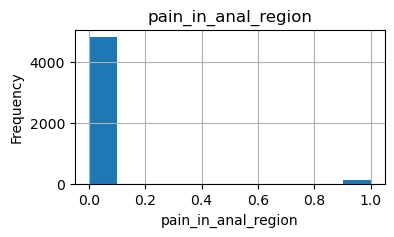

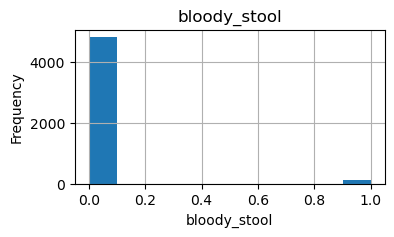

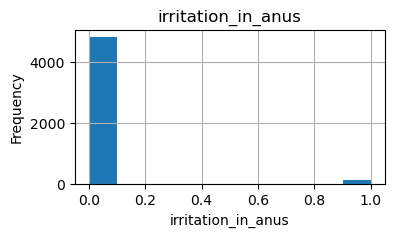

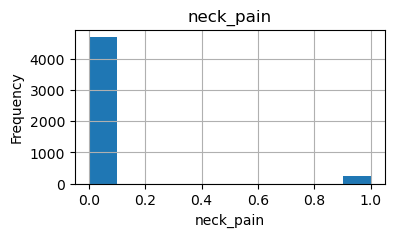

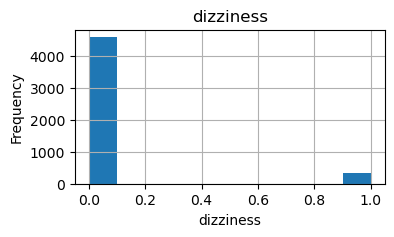

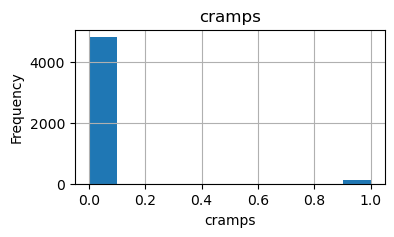

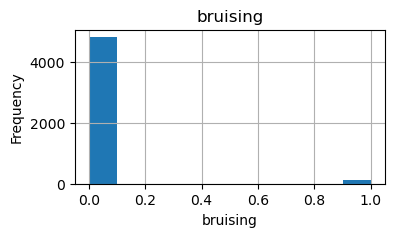

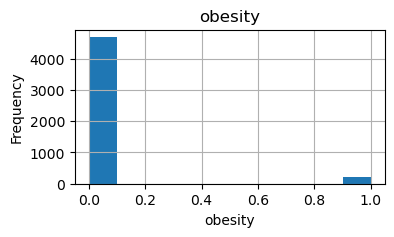

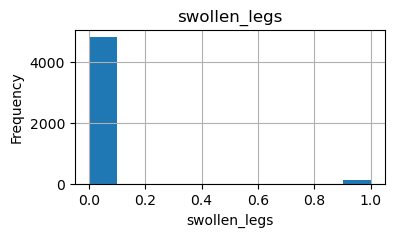

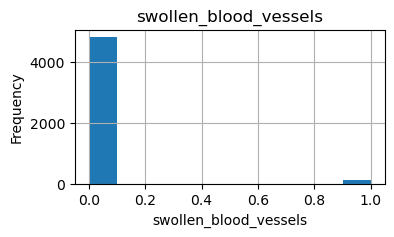

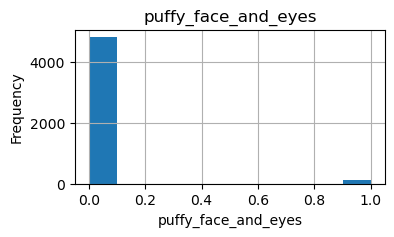

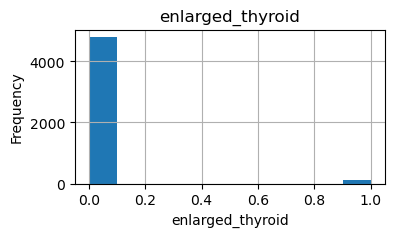

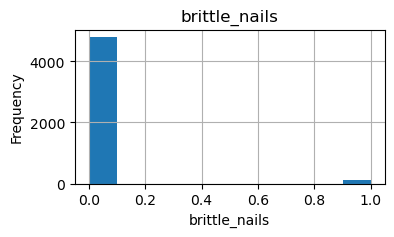

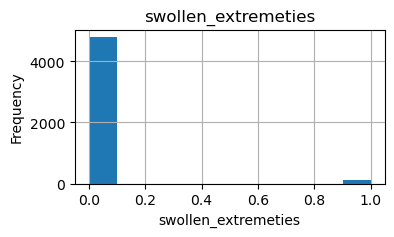

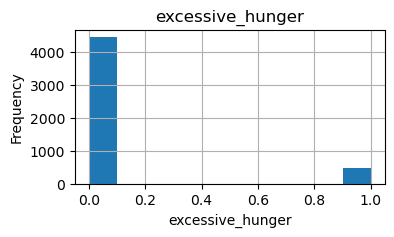

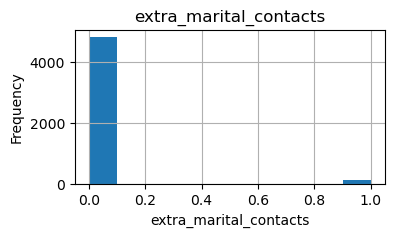

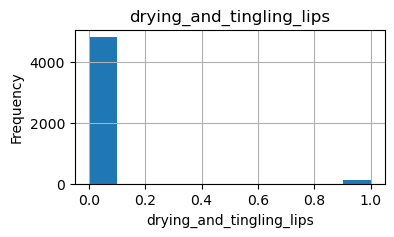

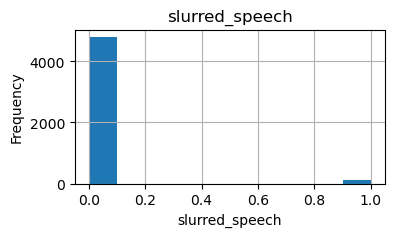

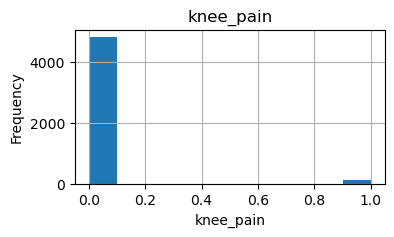

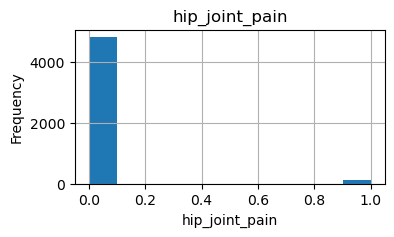

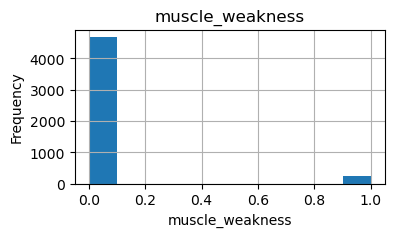

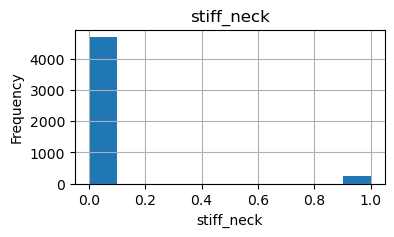

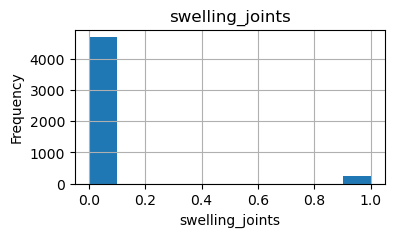

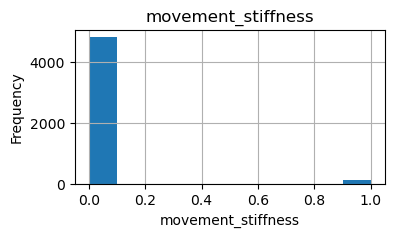

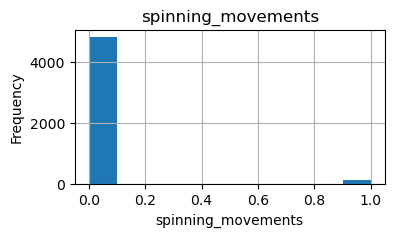

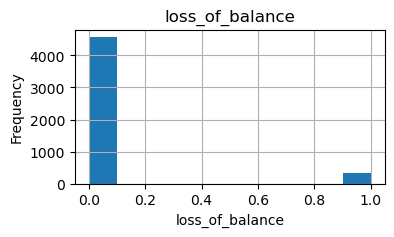

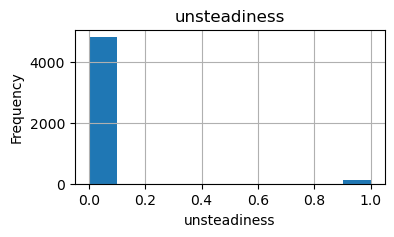

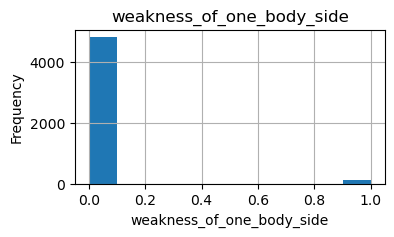

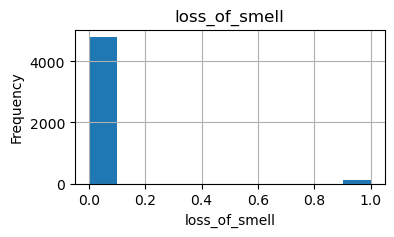

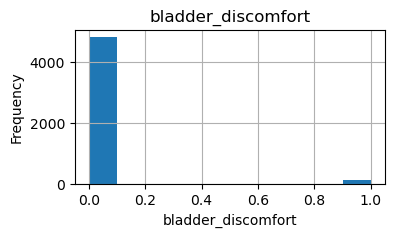

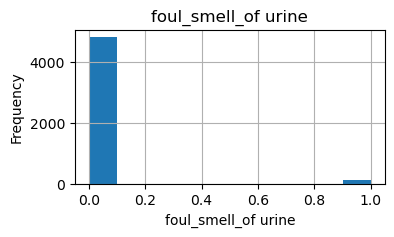

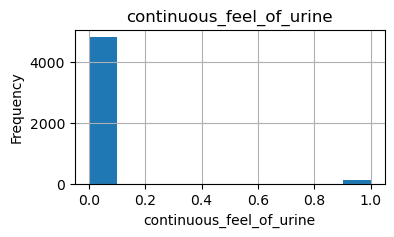

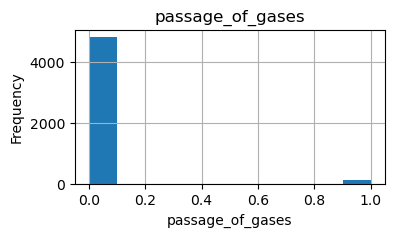

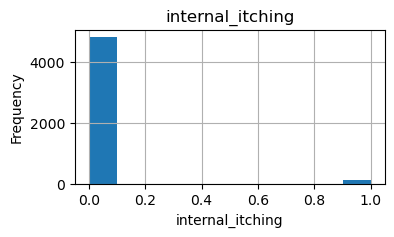

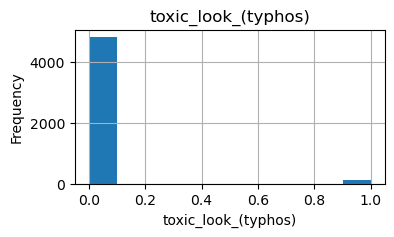

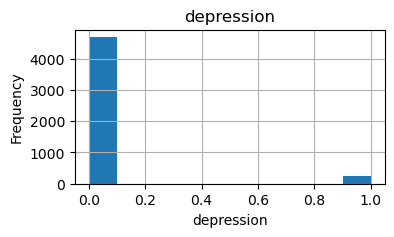

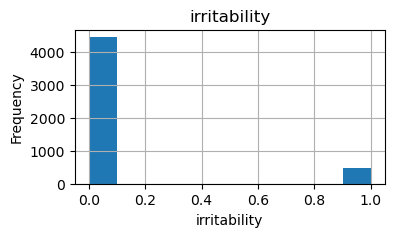

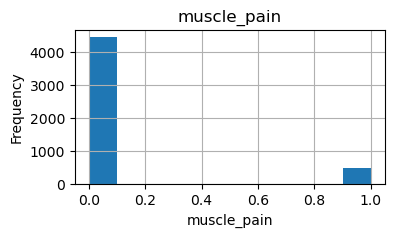

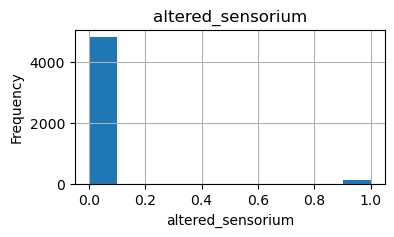

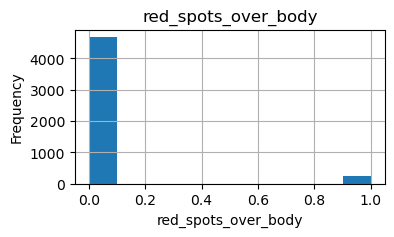

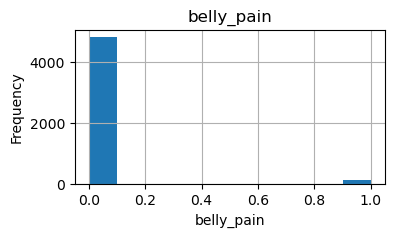

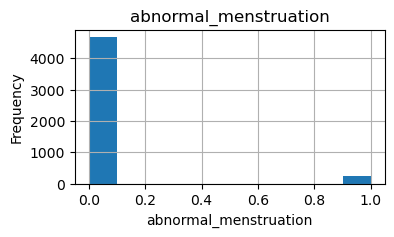

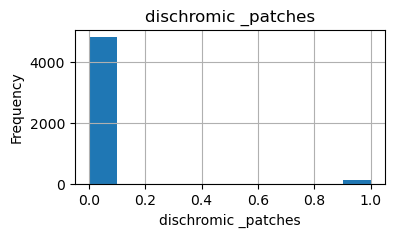

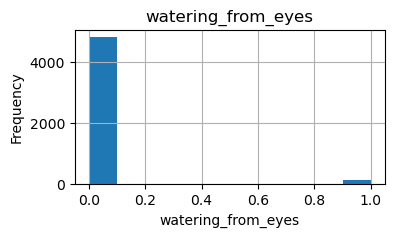

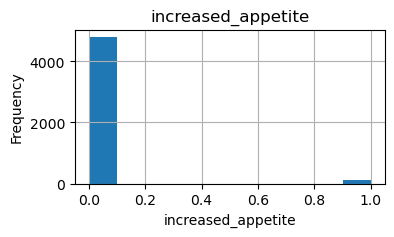

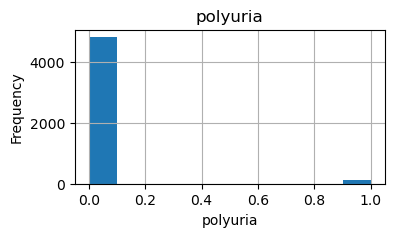

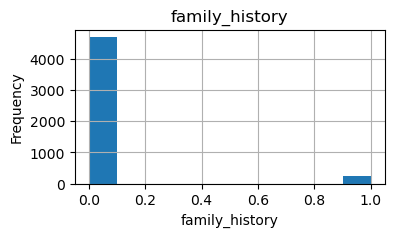

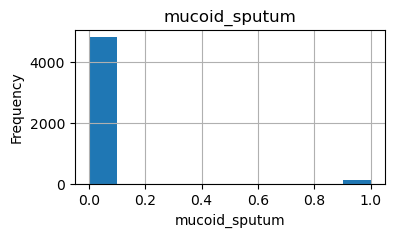

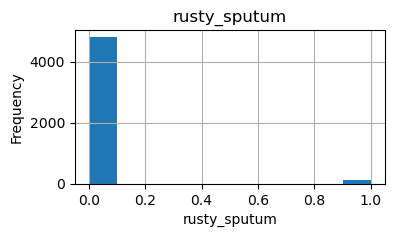

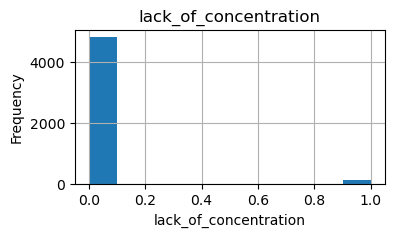

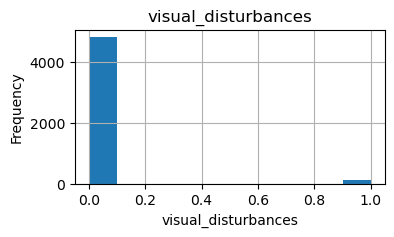

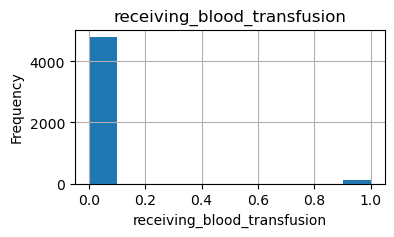

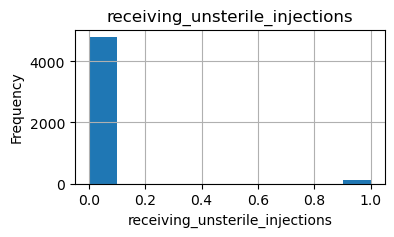

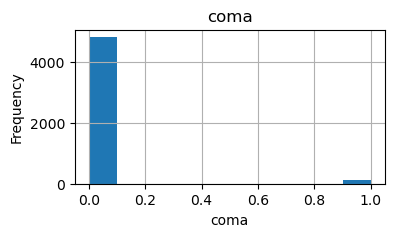

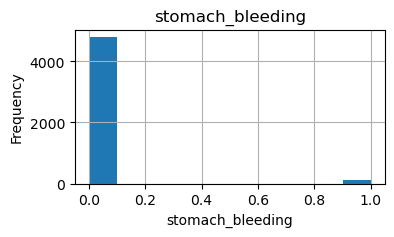

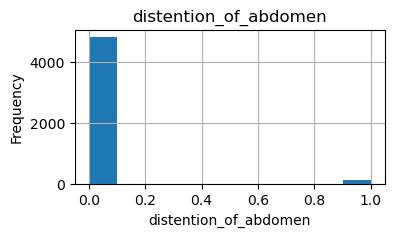

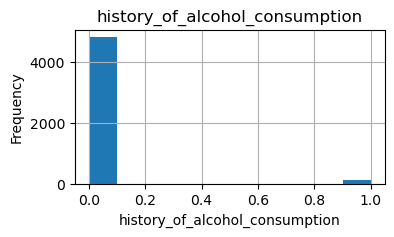

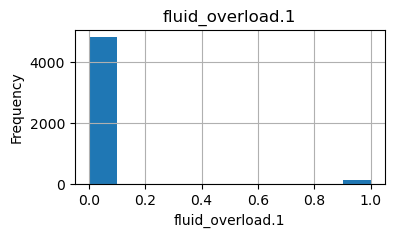

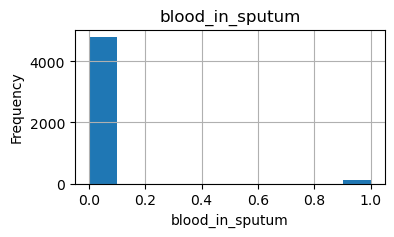

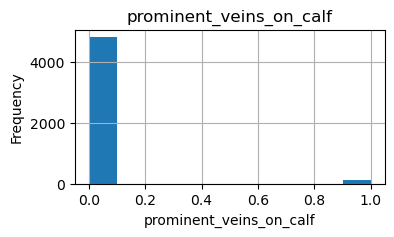

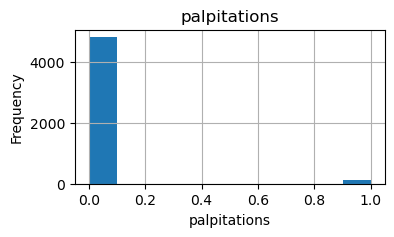

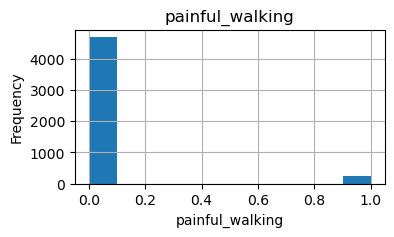

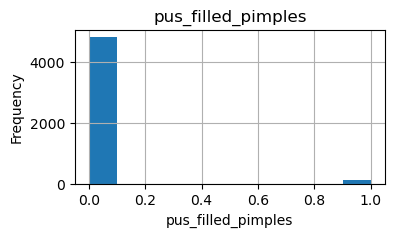

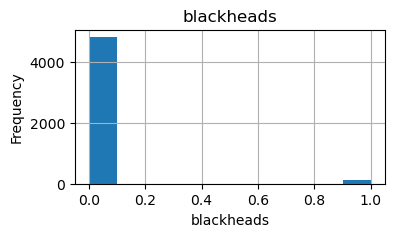

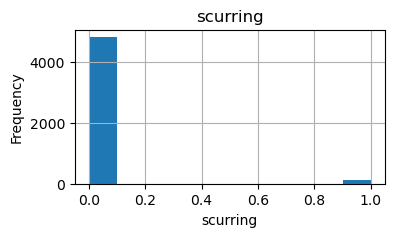

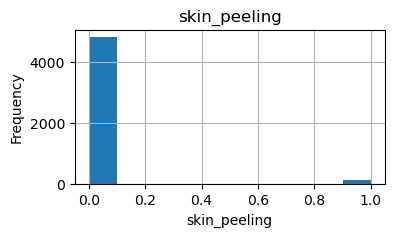

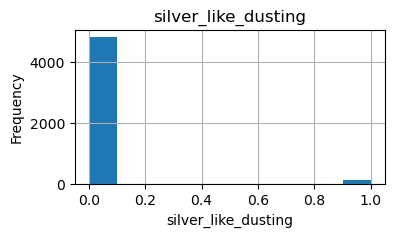

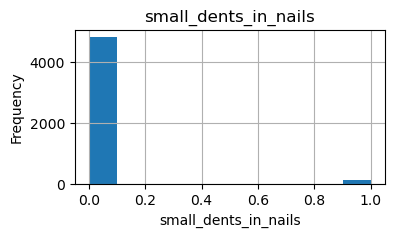

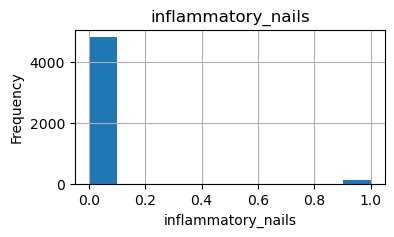

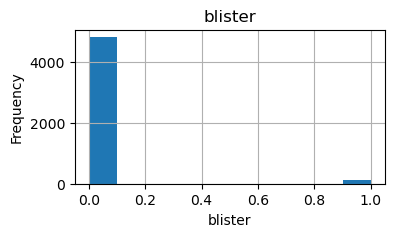

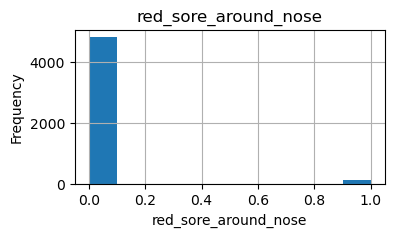

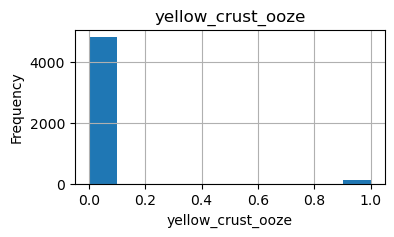

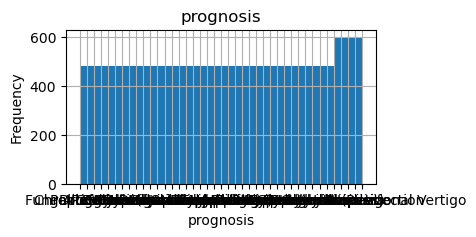

In [120]:
for column in df.columns:
    plt.figure(figsize=(4, 2))  # Set figure size for each plot
    df[column].hist(bins=10)    # Plot histogram with 30 bins (adjust if needed)
    plt.title(column)           # Title as the column name
    plt.xlabel(column)           # Label the x-axis
    plt.ylabel("Frequency")     # Label the y-axis
    plt.show()    

In [122]:
models = {
    "SVC":SVC(kernel='linear'),
    "RandomForestClassifier":RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoostingClassifier":GradientBoostingClassifier(n_estimators=100, random_state=42),
    "KNN":KNeighborsClassifier(n_neighbors=5),
    "MultinomialNB":MultinomialNB()    
}

for model_name, model in models.items():
    # Model Training
    model.fit(X_train, Y_train)
    
    # Model Testing
    predictions = model.predict(X_test)
    
    # Calculating Accuracy
    accuracy = accuracy_score(Y_test, predictions)

    # Confusion Matrix
    cm = confusion_matrix(Y_test, predictions)

    print(f"{model_name} accuracy : {accuracy}")
    print(f"{model_name} Confusion Matrix:")
    print(np.array2string(cm, separator=','))

    
    

    

SVC accuracy : 1.0
SVC Confusion Matrix:
[[40, 0, 0,..., 0, 0, 0],
 [ 0,43, 0,..., 0, 0, 0],
 [ 0, 0,28,..., 0, 0, 0],
 ...,
 [ 0, 0, 0,...,34, 0, 0],
 [ 0, 0, 0,..., 0,41, 0],
 [ 0, 0, 0,..., 0, 0,31]]
RandomForestClassifier accuracy : 1.0
RandomForestClassifier Confusion Matrix:
[[40, 0, 0,..., 0, 0, 0],
 [ 0,43, 0,..., 0, 0, 0],
 [ 0, 0,28,..., 0, 0, 0],
 ...,
 [ 0, 0, 0,...,34, 0, 0],
 [ 0, 0, 0,..., 0,41, 0],
 [ 0, 0, 0,..., 0, 0,31]]
GradientBoostingClassifier accuracy : 1.0
GradientBoostingClassifier Confusion Matrix:
[[40, 0, 0,..., 0, 0, 0],
 [ 0,43, 0,..., 0, 0, 0],
 [ 0, 0,28,..., 0, 0, 0],
 ...,
 [ 0, 0, 0,...,34, 0, 0],
 [ 0, 0, 0,..., 0,41, 0],
 [ 0, 0, 0,..., 0, 0,31]]
KNN accuracy : 1.0
KNN Confusion Matrix:
[[40, 0, 0,..., 0, 0, 0],
 [ 0,43, 0,..., 0, 0, 0],
 [ 0, 0,28,..., 0, 0, 0],
 ...,
 [ 0, 0, 0,...,34, 0, 0],
 [ 0, 0, 0,..., 0,41, 0],
 [ 0, 0, 0,..., 0, 0,31]]
MultinomialNB accuracy : 1.0
MultinomialNB Confusion Matrix:
[[40, 0, 0,..., 0, 0, 0],
 [ 0,43, 0,..., 0

In [124]:
RFC= RandomForestClassifier(n_estimators=100, random_state=42)
RFC.fit(X_train,Y_train)
RFCpred= RFC.predict(X_test)
accuracy_score(Y_test, RFCpred)

1.0

In [126]:
# Saving Model
import pickle
pickle.dump(RFC,open("Desktop/FYP/models/RFC.pkl",'wb'))

In [128]:
# Loading Model
pickle.load(open("Desktop/FYP/models/RFC.pkl",'rb'))

RandomForestClassifier(random_state=42)

In [213]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
# Test
print("Predicted :",RFC.predict(X_test.iloc[0].values.reshape(1,-1)))
print("Actual :", Y_test[0])

Predicted : [40]
Actual : 40


In [215]:
# Test
print("Predicted :",RFC.predict(X_test.iloc[15].values.reshape(1,-1)))
print("Actual :", Y_test[15])

Predicted : [11]
Actual : 11


                                                    RECOMMENDATION SYSTEM AND PREDICTION

In [135]:
symptom_description = pd.read_csv(r"C:\Users\Gamer Tech\Desktop\FYP\Data\symptoms_df.csv")

In [137]:
symptom_description 

,Unnamed: 0,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4
0,0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches
1,1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN
2,2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN
3,3,Fungal infection,itching,skin_rash,dischromic _patches,NaN
4,4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN
...,...,...,...,...,...,...
4915,4915,(vertigo) Paroymsal Positional Vertigo,vomiting,headache,nausea,spinning_movements
4916,4916,Acne,skin_rash,pus_filled_pimples,blackheads,scurring
4917,4917,Urinary tract infection,burning_micturition,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine
4918,4918,Psoriasis,skin_rash,joint_pain,skin_peeling,silver_like_dusting


In [139]:
symptom_description = symptom_description.drop(symptom_description.columns[0],axis=1) 

In [141]:
symptom_description 

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN
...,...,...,...,...,...
4915,(vertigo) Paroymsal Positional Vertigo,vomiting,headache,nausea,spinning_movements
4916,Acne,skin_rash,pus_filled_pimples,blackheads,scurring
4917,Urinary tract infection,burning_micturition,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine
4918,Psoriasis,skin_rash,joint_pain,skin_peeling,silver_like_dusting


In [143]:
precaution = pd.read_csv(r"C:\Users\Gamer Tech\Desktop\FYP\Data\precautions_df.csv")

In [145]:
precaution

,Unnamed: 0,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths
5,5,GERD,avoid fatty spicy food,avoid lying down after eating,maintain healthy weight,exercise
6,6,Chronic cholestasis,cold baths,anti itch medicine,consult doctor,eat healthy
7,7,hepatitis A,Consult nearest hospital,wash hands through,avoid fatty spicy food,medication
8,8,Osteoarthristis,acetaminophen,consult nearest hospital,follow up,salt baths
9,9,(vertigo) Paroymsal Positional Vertigo,lie down,avoid sudden change in body,avoid abrupt head movment,relax


In [147]:
precaution = precaution.drop(precaution.columns[0],axis=1) 

In [149]:
precaution

,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths
5,GERD,avoid fatty spicy food,avoid lying down after eating,maintain healthy weight,exercise
6,Chronic cholestasis,cold baths,anti itch medicine,consult doctor,eat healthy
7,hepatitis A,Consult nearest hospital,wash hands through,avoid fatty spicy food,medication
8,Osteoarthristis,acetaminophen,consult nearest hospital,follow up,salt baths
9,(vertigo) Paroymsal Positional Vertigo,lie down,avoid sudden change in body,avoid abrupt head movment,relax


In [207]:
medication = pd.read_csv(r"C:\Users\Gamer Tech\Desktop\FYP\Data\medications.csv")
description = pd.read_csv(r"C:\Users\Gamer Tech\Desktop\FYP\Data\description.csv")
diet = pd.read_csv(r"C:\Users\Gamer Tech\Desktop\FYP\Data\diets.csv")

In [309]:
def helper(dis):
    desc = description[description['Disease'] == dis]['Description']
    desc = " ".join([w for w in desc])

    pre = precaution[precaution['Disease'] == dis][['Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']]
    pre = [col for col in pre.values]

    med = medication[medication['Disease'] == dis]['Medication']
    med = [med for med in med.values]

    die = diet[diet['Disease'] == dis]['Diet']
    die = [die for die in die.values]

    return desc,pre,med,die


symptoms_dict = {'itching': 0, 'skin_rash': 1, 'nodal_skin_eruptions': 2, 'continuous_sneezing': 3, 'shivering': 4, 'chills': 5, 'joint_pain': 6, 'stomach_pain': 7, 'acidity': 8, 'ulcers_on_tongue': 9, 'muscle_wasting': 10, 'vomiting': 11, 'burning_micturition': 12, 'spotting_ urination': 13, 'fatigue': 14, 'weight_gain': 15, 'anxiety': 16, 'cold_hands_and_feets': 17, 'mood_swings': 18, 'weight_loss': 19, 'restlessness': 20, 'lethargy': 21, 'patches_in_throat': 22, 'irregular_sugar_level': 23, 'cough': 24, 'high_fever': 25, 'sunken_eyes': 26, 'breathlessness': 27, 'sweating': 28, 'dehydration': 29, 'indigestion': 30, 'headache': 31, 'yellowish_skin': 32, 'dark_urine': 33, 'nausea': 34, 'loss_of_appetite': 35, 'pain_behind_the_eyes': 36, 'back_pain': 37, 'constipation': 38, 'abdominal_pain': 39, 'diarrhoea': 40, 'mild_fever': 41, 'yellow_urine': 42, 'yellowing_of_eyes': 43, 'acute_liver_failure': 44, 'fluid_overload': 45, 'swelling_of_stomach': 46, 'swelled_lymph_nodes': 47, 'malaise': 48, 'blurred_and_distorted_vision': 49, 'phlegm': 50, 'throat_irritation': 51, 'redness_of_eyes': 52, 'sinus_pressure': 53, 'runny_nose': 54, 'congestion': 55, 'chest_pain': 56, 'weakness_in_limbs': 57, 'fast_heart_rate': 58, 'pain_during_bowel_movements': 59, 'pain_in_anal_region': 60, 'bloody_stool': 61, 'irritation_in_anus': 62, 'neck_pain': 63, 'dizziness': 64, 'cramps': 65, 'bruising': 66, 'obesity': 67, 'swollen_legs': 68, 'swollen_blood_vessels': 69, 'puffy_face_and_eyes': 70, 'enlarged_thyroid': 71, 'brittle_nails': 72, 'swollen_extremeties': 73, 'excessive_hunger': 74, 'extra_marital_contacts': 75, 'drying_and_tingling_lips': 76, 'slurred_speech': 77, 'knee_pain': 78, 'hip_joint_pain': 79, 'muscle_weakness': 80, 'stiff_neck': 81, 'swelling_joints': 82, 'movement_stiffness': 83, 'spinning_movements': 84, 'loss_of_balance': 85, 'unsteadiness': 86, 'weakness_of_one_body_side': 87, 'loss_of_smell': 88, 'bladder_discomfort': 89, 'foul_smell_of urine': 90, 'continuous_feel_of_urine': 91, 'passage_of_gases': 92, 'internal_itching': 93, 'toxic_look_(typhos)': 94, 'depression': 95, 'irritability': 96, 'muscle_pain': 97, 'altered_sensorium': 98, 'red_spots_over_body': 99, 'belly_pain': 100, 'abnormal_menstruation': 101, 'dischromic _patches': 102, 'watering_from_eyes': 103, 'increased_appetite': 104, 'polyuria': 105, 'family_history': 106, 'mucoid_sputum': 107, 'rusty_sputum': 108, 'lack_of_concentration': 109, 'visual_disturbances': 110, 'receiving_blood_transfusion': 111, 'receiving_unsterile_injections': 112, 'coma': 113, 'stomach_bleeding': 114, 'distention_of_abdomen': 115, 'history_of_alcohol_consumption': 116, 'fluid_overload.1': 117, 'blood_in_sputum': 118, 'prominent_veins_on_calf': 119, 'palpitations': 120, 'painful_walking': 121, 'pus_filled_pimples': 122, 'blackheads': 123, 'scurring': 124, 'skin_peeling': 125, 'silver_like_dusting': 126, 'small_dents_in_nails': 127, 'inflammatory_nails': 128, 'blister': 129, 'red_sore_around_nose': 130, 'yellow_crust_ooze': 131}
diseases_list = {15: 'Fungal infection', 4: 'Allergy', 16: 'GERD', 9: 'Chronic cholestasis', 14: 'Drug Reaction', 33: 'Peptic ulcer diseae', 1: 'AIDS', 12: 'Diabetes ', 17: 'Gastroenteritis', 6: 'Bronchial Asthma', 23: 'Hypertension ', 30: 'Migraine', 7: 'Cervical spondylosis', 32: 'Paralysis (brain hemorrhage)', 28: 'Jaundice', 29: 'Malaria', 8: 'Chicken pox', 11: 'Dengue', 37: 'Typhoid', 40: 'hepatitis A', 19: 'Hepatitis B', 20: 'Hepatitis C', 21: 'Hepatitis D', 22: 'Hepatitis E', 3: 'Alcoholic hepatitis', 36: 'Tuberculosis', 10: 'Common Cold', 34: 'Pneumonia', 13: 'Dimorphic hemmorhoids(piles)', 18: 'Heart attack', 39: 'Varicose veins', 26: 'Hypothyroidism', 24: 'Hyperthyroidism', 25: 'Hypoglycemia', 31: 'Osteoarthristis', 5: 'Arthritis', 0: '(vertigo) Paroymsal  Positional Vertigo', 2: 'Acne', 38: 'Urinary tract infection', 35: 'Psoriasis', 27: 'Impetigo'}

def get_prediction(patient_symptoms):
    symptom_list= np.zeros(len(symptoms_dict))
    for item in patient_symptoms:
        symptom_list[symptoms_dict[item]]=1
    return  diseases_list [RFC.predict([symptom_list])[0]]


In [311]:
# Test
symptom= input("Enter your symptoms")
user_symptom = [s.strip() for s in symptom.split(',')]
user_symptom=[symptom.strip("[]'") for symptom in user_symptom]
prediction=get_prediction(user_symptom)


desc, pre, med, die = helper(prediction)

print("=================predicted disease============")
print(prediction)
print("=================description==================")
print(desc)
print("=================precautions==================")
i = 1
for p_i in pre[0]:
    print(i, ": ", p_i)
    i += 1

print("=================medications==================")
for m_i in med:
    print(i, ": ", m_i)
    i += 1



print("=================diets==================")
for d_i in die:
    print(i, ": ", d_i)
    i += 1

Enter your symptoms itching, skin_rash


=================predicted disease============
Fungal infection
=================description==================
Fungal infection is a common skin condition caused by fungi.
=================precautions==================
1 :  bath twice
2 :  use detol or neem in bathing water
3 :  keep infected area dry
4 :  use clean cloths
=================medications==================
5 :  ['Antifungal Cream', 'Fluconazole', 'Terbinafine', 'Clotrimazole', 'Ketoconazole']
=================diets==================
6 :  ['Antifungal Diet', 'Probiotics', 'Garlic', 'Coconut oil', 'Turmeric']
